In [1]:
import os
from importlib import reload
import sys
sys.path.insert(
    0, r'C:\Users\richa\GitHub\py_neuromodulation\pyneuromodulation')

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from pybv import write_brainvision
import mne
import mne_bids

import start_BIDS
import define_M1


def get_all_files(path, suffix, get_bids=False, prefix=None, bids_root=None,
                  verbose=False, extension=None):
    """Return all files in all (sub-)directories of path with given suffixes and prefixes (case-insensitive).

    Args:
        path (string)
        suffix (iterable): e.g. ["vhdr", "edf"] or ".json"
        get_bids (boolean): True if BIDS_Path type should be returned instead of string. Default: False
        bids_root (string/path): Path of BIDS root folder. Only required if get_bids=True.
        prefix (iterable): e.g. ["SelfpacedRota", "ButtonPress] (optional)

    Returns:
        filepaths (list of strings or list of BIDS_Path)
    """

    if isinstance(suffix, str):
        suffix = [suffix]
    if isinstance(prefix, str):
        prefix = [prefix]

    filepaths = []
    for root, dirs, files in os.walk(path):
        for file in files:
            for suff in suffix:
                if file.endswith(suff.lower()):
                    if not prefix:
                        filepaths.append(os.path.join(root, file))
                    else:
                        for pref in prefix:
                            if pref.lower() in file.lower():
                                filepaths.append(os.path.join(root, file))

    bids_paths = filepaths
    if get_bids:
        if not bids_root:
            print(
                "Warning: No root folder given. Please pass bids_root parameter to create a complete BIDS_Path object.")
        bids_paths = []
        for filepath in filepaths:
            entities = mne_bids.get_entities_from_fname(filepath)
            try:
                bids_path = mne_bids.BIDSPath(subject=entities["subject"],
                                              session=entities["session"],
                                              task=entities["task"],
                                              run=entities["run"],
                                              acquisition=entities[
                                                  "acquisition"],
                                              suffix=entities["suffix"],
                                              extension=extension,
                                              root=bids_root)
            except ValueError as err:
                print(
                    f"ValueError while creating BIDS_Path object for file {filepath}: {err}")
            else:
                bids_paths.append(bids_path)

    if verbose:
        if not bids_paths:
            print("No corresponding files found.")
        else:
            print('Corresponding files found:')
            for idx, file in enumerate(bids_paths):
                print(idx, ':', os.path.basename(file))

    return bids_paths

def bids_rewrite_file(raw, bids_path, return_raw=False):
    """Overwrite BrainVision data in BIDS format that has been modified.

    Parameters
    ----------
    raw : raw MNE object
        The raw MNE object for this function to write
    bids_path : BIDSPath MNE-BIDS object
        The MNE BIDSPath to the file to be overwritten
    return_raw : boolean, optional
        Set to True to return the new raw object that has been written.
        Default is False.
    Returns
    -------
    raw_new : raw MNE object or None
        The newly written raw object.
    """
    bids_path.update(suffix=bids_path.datatype, extension=None)

    data = raw.get_data()
    sfreq = raw.info['sfreq']
    ch_names = raw.ch_names
    fname = bids_path.basename
    folder = bids_path.directory
    events, event_id = mne.events_from_annotations(raw)
    events_new = np.vstack((events[:, 0], events[:, 2])).T

    # rewrite datafile
    write_brainvision(data=data, sfreq=sfreq, ch_names=ch_names,
                      fname_base='dummy', folder_out=folder,
                      events=events_new)
    suffixes = ['.eeg', '.vhdr', '.vmrk']
    orig_files = [os.path.join(folder, fname + suffix)
                  for suffix in suffixes]
    for orig_file in orig_files:
        os.remove(orig_file)
    source_path = os.path.join(folder, 'dummy' + '.vhdr')
    dest_path = os.path.join(folder, fname + '.vhdr')
    mne_bids.copyfiles.copyfile_brainvision(source_path, dest_path)
    dummy_files = [os.path.join(folder, 'dummy' + suffix)
                   for suffix in suffixes]
    for dummy_file in dummy_files:
        os.remove(dummy_file)

    # rewrite events.tsv
    channels_path = bids_path.copy().update(suffix='channels')
    channels_tsv = channels_path.fpath
    df = pd.read_csv(channels_tsv, sep='\t', index_col=0)
    old_chs = df.index.tolist()
    add_chs = [ch for ch in raw.ch_names if ch not in old_chs]
    description = {'seeg': 'StereoEEG', 'ecog': 'Electrocorticography',
                   'eeg': 'Electroencephalography', 'emg': 'Electromyography',
                   'misc': 'Miscellaneous', 'dbs': 'Deep Brain Stimulation'}
    add_list = []
    ch_types = raw.get_channel_types(picks=add_chs)
    print("Added channels: ", add_chs)
    print("Added channel types: ", ch_types)
    for idx, add_ch in enumerate(add_chs):
        add_dict = {}
        add_dict.update({df.columns[i]: df.iloc[0][i]
                         for i in range(0, len(df.columns))})
        add_dict.update({'type': ch_types[idx].upper()})
        add_dict.update({'description': description.get(ch_types[idx])})
        add_list.append(add_dict)
    index = pd.Index(add_chs, name='name')
    df_add = pd.DataFrame(add_list, index=index)
    df = df.append(df_add, ignore_index=False)
    remov_chs = [ch for ch in old_chs if ch not in raw.ch_names]
    df = df.drop(remov_chs)
    df = df.reindex(raw.ch_names)
    os.remove(channels_tsv)
    df.to_csv(os.path.join(folder, channels_path.basename + '.tsv'),
              sep='\t', na_rep='n/a', index=True)
    # rewrite **electrodes.tsv
    elec_files = []
    for file in os.listdir(folder):
        if file.endswith('_electrodes.tsv') and '_space-' in file:
            elec_files.append(os.path.join(folder, file))
    for elec_file in elec_files:
        df = pd.read_csv(elec_file, sep='\t', index_col=0)
        old_chs = df.index.tolist()
        add_chs = [ch for ch in raw.ch_names if ch not in old_chs]
        add_list = []
        for add_ch in add_chs:
            add_dict = {}
            add_dict.update({column: 'n/a' for column in df.columns})
            add_list.append(add_dict)
        index = pd.Index(add_chs, name='name')
        df_add = pd.DataFrame(add_list, index=index)
        df = df.append(df_add, ignore_index=False)
        remov_chs = [ch for ch in old_chs if ch not in raw.ch_names]
        df = df.drop(remov_chs)
        df = df.reindex(raw.ch_names)
        os.remove(elec_file)
        df.to_csv(os.path.join(elec_file), sep='\t', na_rep='n/a',
                  index=True)
    # check for success
    raw = mne_bids.read_raw_bids(bids_path, verbose=False)
    if return_raw is True:
        return raw

def add_squared_channel(raw, event_id):
    """

    :param raw:
    :param event_id:
    :return:
    """
    events, event_id = mne.events_from_annotations(
        raw, event_id)
    data = raw.get_data()
    evs_idx = events[:, 0]
    onoff = np.zeros((1, data.shape[1]))
    for i in np.arange(0, len(evs_idx), 2):
        onoff[0, evs_idx[i]:evs_idx[i + 1]] = 1
    info = mne.create_info(ch_names=['rota_squared'],
                           ch_types=['misc'], sfreq=raw.info['sfreq'])
    raw_sq = mne.io.RawArray(onoff, info)
    raw_sq.info['meas_date'] = raw.info['meas_date']
    raw_sq.info['line_freq'] = 50
    raw_final = raw.copy().load_data().add_channels(
        [raw_sq], force_update_info=True)
    return raw_final

def add_summation_channel(raw, sum_channels, new_ch):
    """

    :param raw:
    :param sum_channels:
    :param new_ch:
    :return:
    """
    data = raw.get_data(picks=sum_channels)
    new_data = np.expand_dims(data.sum(axis=0), axis=0)
    ch_type = raw.get_channel_types(picks=sum_channels[0])
    info = mne.create_info(
        [new_ch], sfreq=raw.info['sfreq'], ch_types=ch_type, verbose=False)
    raw_new = mne.io.RawArray(
        new_data, info, first_samp=0, copy='auto', verbose=False)
    raw_final = raw.copy().load_data().add_channels(
        [raw_new], force_update_info=True)
    return raw_final

In [2]:
root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26'
source_files = get_all_files(
    path=root,
    suffix='vhdr',
    get_bids=True,
    prefix='SelfpacedRotation',
    bids_root=root,
    verbose=True,
    extension=None)
out_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26_rereference-ECOG\derivatives\feat_mne_tf'

Corresponding files found:
0 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr
1 : sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr
2 : sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr
3 : sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg.vhdr
4 : sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr
5 : sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr
6 : sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg.vhdr
7 : sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr
8 : sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg.vhdr
9 : sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr
10 : sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg.vhdr
11 : sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-Stim

In [3]:
contralateral = [
    'sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg']

In [4]:
files = list()
for file in source_files:
    if any([item == file.basename for item in contralateral]):
        files.append(file)
        print(file.basename)

sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg


# File 0

In [31]:
ind = 0
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff01\ieeg\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff01\ieeg\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff01\ieeg\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_channels.tsv.


<ipython-input-31-7f15745c38da>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\**\sub-002_ses-EphysMedOff01*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-31-7f15745c38da>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\**\sub-002_ses-EphysMedOff01*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [32]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 695826  =      0.000 ...   506.055 secs...


In [33]:
anodes = [
'LFP_R_234_STN_BS',
'LFP_R_567_STN_BS',
'LFP_R_8_STN_BS',
'LFP_R_8_STN_BS',
'LFP_L_234_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_8_STN_BS',
'LFP_L_8_STN_BS']
cathodes = [
'LFP_R_1_STN_BS',
'LFP_R_234_STN_BS',
'LFP_R_567_STN_BS',
'LFP_R_1_STN_BS',
'LFP_L_1_STN_BS',
'LFP_L_234_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_1_STN_BS']
new_chs =[
'STN_R_1_234_BS',
'STN_R_234_567_BS',
'STN_R_567_8_BS',
'STN_R_1_8_BS',
'STN_L_1_234_BS',
'STN_L_234_567_BS',
'STN_L_567_8_BS',
'STN_L_1_8_BS'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=695827
    Range : 0 ... 695826 =      0.000 ...   506.055 secs
Ready.
Added the following bipolar channels:
STN_R_1_234_BS, STN_R_234_567_BS, STN_R_567_8_BS, STN_R_1_8_BS, STN_L_1_234_BS, STN_L_234_567_BS, STN_L_567_8_BS, STN_L_1_8_BS


In [34]:
picks = sorted([
'ECOG_L_1_SMC_AT',
'ECOG_L_2_SMC_AT',
'ECOG_L_3_SMC_AT',
'ECOG_L_4_SMC_AT',
'ECOG_L_5_SMC_AT',
'ECOG_L_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [35]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 9077 samples (6.601 sec)



In [36]:
raw.ch_names

['ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'STN_L_1_234_BS',
 'STN_L_1_8_BS',
 'STN_L_234_567_BS',
 'STN_L_567_8_BS',
 'STN_R_1_234_BS',
 'STN_R_1_8_BS',
 'STN_R_234_567_BS',
 'STN_R_567_8_BS',
 'rota_squared']

In [37]:
raw = raw.resample(sfreq=500)

In [38]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [39]:
tf.shape

(14, 200, 253028)

In [40]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [41]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [16]:
raw.annotations

<Annotations | 140 segments: rotation_end (70), rotation_onset (70)>

In [42]:
events, event_id = mne.events_from_annotations(raw, {'rotation_onset':1,
                                                     'rotation_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<5.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['rotation_end', 'rotation_onset']
Orig. no. of events:  140 , Orig. no. of trials:  70
New no. of events:  126 , New no. of trials:  63
Dropped no. of trials:  7
Intertrial pauses:  [3.56  4.516 5.152 4.346 4.898 4.592 4.236 3.922 7.496 6.59  6.574 6.092
 6.67  6.698 7.47  6.662 6.084 6.59  6.492 7.394 7.72  7.142 6.59  7.334
 6.062 6.764 6.588 6.718 6.    7.38  6.382 6.732 6.478 6.152 6.804 6.294
 5.978 6.516 7.078 7.31  6.614 7.29  6.518 6.314 5.928 6.948 6.68  7.002
 7.312 6.206 6.788 6.864 6.79  7.082 6.408 6.63  6.644 7.246 7.304 6.854
 6.71  7.776 7.276 6.88  7.044 6.408 6.882 6.97  6.242]


In [44]:
features['rota_squared'] = onoff[::decim]

In [48]:
df = pd.DataFrame(features)

In [49]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [50]:
df = pd.read_csv(out_file, index_col=None)

# File 1

In [52]:
ind = 1
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff02\ieeg\sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff02\ieeg\sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff02\ieeg\sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_channels.tsv.
sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg


<ipython-input-52-5ed641117454>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\**\sub-002_ses-EphysMedOff02*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-52-5ed641117454>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\**\sub-002_ses-EphysMedOff02*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [53]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 613327  =      0.000 ...   446.056 secs...


In [55]:
raw.ch_names

['LFP_R_234_STN_BS',
 'LFP_R_567_STN_BS',
 'LFP_L_1_STN_BS',
 'LFP_L_234_STN_BS',
 'LFP_L_567_STN_BS',
 'ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'ANALOG_R_ROTA_CH',
 'EEG_AO',
 'rota_squared']

In [58]:
anodes = [
'LFP_R_567_STN_BS',
'LFP_L_234_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_567_STN_BS']
cathodes = [
'LFP_R_234_STN_BS',
'LFP_L_1_STN_BS',
'LFP_L_234_STN_BS',
'LFP_L_1_STN_BS']
new_chs =[
'STN_R_234_567_BS',
'STN_L_1_234_BS',
'STN_L_234_567_BS',
'STN_L_1_567_BS'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=4, n_times=613328
    Range : 0 ... 613327 =      0.000 ...   446.056 secs
Ready.
Added the following bipolar channels:
STN_R_234_567_BS, STN_L_1_234_BS, STN_L_234_567_BS, STN_L_1_567_BS


In [59]:
picks = sorted([
'ECOG_L_1_SMC_AT',
'ECOG_L_2_SMC_AT',
'ECOG_L_3_SMC_AT',
'ECOG_L_4_SMC_AT',
'ECOG_L_5_SMC_AT',
'ECOG_L_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [60]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 9075 samples (6.600 sec)



In [61]:
raw.ch_names

['ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'STN_L_1_234_BS',
 'STN_L_1_567_BS',
 'STN_L_234_567_BS',
 'STN_R_234_567_BS',
 'rota_squared']

In [62]:
raw = raw.resample(sfreq=500)

In [63]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [64]:
tf.shape

(10, 200, 223028)

In [65]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [66]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [67]:
raw.annotations

<Annotations | 104 segments: rotation_end (52), rotation_onset (52)>

In [68]:
events, event_id = mne.events_from_annotations(raw, {'rotation_onset':1,
                                                     'rotation_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<5.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['rotation_end', 'rotation_onset']
Orig. no. of events:  104 , Orig. no. of trials:  52
New no. of events:  96 , New no. of trials:  48
Dropped no. of trials:  4
Intertrial pauses:  [5.028 5.128 4.774 5.124 4.952 4.94  5.008 5.252 4.59  5.288 5.864 5.356
 5.146 5.092 5.968 5.974 5.184 5.282 7.52  7.924 7.606 6.962 6.366 7.396
 7.224 7.428 7.948 7.222 8.512 7.58  6.838 7.99  7.916 8.136 8.676 7.444
 8.47  8.628 6.95  8.682 7.334 6.894 6.25  7.108 7.972 7.372 7.23  7.096
 7.922 6.902 7.58 ]


In [69]:
features['rota_squared'] = onoff[::decim]

In [70]:
df = pd.DataFrame(features)

In [71]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [72]:
df = pd.read_csv(out_file, index_col=None)

# File 2

In [73]:
ind = 2
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff03\ieeg\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff03\ieeg\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\ses-EphysMedOff03\ieeg\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_channels.tsv.
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg


<ipython-input-73-8b3f50adc590>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\**\sub-002_ses-EphysMedOff03*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-73-8b3f50adc590>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-002\**\sub-002_ses-EphysMedOff03*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [74]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 675533  =      0.000 ...   491.112 secs...


In [75]:
data = raw.get_data(picks=[
'LFP_R_2_STN_BS',
'LFP_R_3_STN_BS',
'LFP_R_4_STN_BS',
'LFP_R_5_STN_BS',
'LFP_R_6_STN_BS',
'LFP_R_7_STN_BS',
'LFP_L_2_STN_BS',
'LFP_L_3_STN_BS',
'LFP_L_4_STN_BS',
'LFP_L_5_STN_BS',
'LFP_L_6_STN_BS',
'LFP_L_7_STN_BS'])

In [76]:
data.shape

(12, 675534)

In [77]:
data_list = list()
for i in np.arange(0, data.shape[0], 3):
    add_data = np.expand_dims(data[i]+data[i+1]+data[i+2], axis=0)
    data_list.append(add_data)
new_data = np.concatenate(data_list, axis=0)

In [78]:
info =  mne.create_info(['LFP_R_234_STN_BS', 'LFP_R_567_STN_BS', 'LFP_L_234_STN_BS', 'LFP_L_567_STN_BS'], 
                        sfreq=raw.info['sfreq'], ch_types='seeg', verbose=None)
raw_new = mne.io.RawArray(new_data, info, first_samp=0, copy='auto', verbose=None)

Creating RawArray with float64 data, n_channels=4, n_times=675534
    Range : 0 ... 675533 =      0.000 ...   491.112 secs
Ready.


In [79]:
raw = raw.add_channels([raw_new], force_update_info=True)

ValueError: The following channels are present in more than one input measurement info objects: ['LFP_R_234_STN_BS', 'LFP_L_234_STN_BS', 'LFP_L_567_STN_BS', 'LFP_R_567_STN_BS']

In [80]:
raw.ch_names

['LFP_R_1_STN_BS',
 'LFP_R_2_STN_BS',
 'LFP_R_3_STN_BS',
 'LFP_R_4_STN_BS',
 'LFP_R_5_STN_BS',
 'LFP_R_6_STN_BS',
 'LFP_R_7_STN_BS',
 'LFP_R_8_STN_BS',
 'LFP_L_1_STN_BS',
 'LFP_L_2_STN_BS',
 'LFP_L_3_STN_BS',
 'LFP_L_4_STN_BS',
 'LFP_L_5_STN_BS',
 'LFP_L_6_STN_BS',
 'LFP_L_7_STN_BS',
 'LFP_L_8_STN_BS',
 'ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'EEG_Cz_AO',
 'EEG_Fz_AO',
 'EMG_BR_R_1_AO',
 'EMG_BR_R_2_AO',
 'EMG_FDI_R_1_AO',
 'EMG_FDI_R_2_AO',
 'ANALOG_R_ROTA_CH',
 'rota_squared',
 'LFP_R_234_STN_BS',
 'LFP_R_567_STN_BS',
 'LFP_L_234_STN_BS',
 'LFP_L_567_STN_BS']

In [83]:
anodes = [
'LFP_R_567_STN_BS',
'LFP_R_234_STN_BS',
'LFP_L_8_STN_BS',
'LFP_L_8_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_234_STN_BS',]
cathodes = [
'LFP_R_234_STN_BS',
'LFP_R_1_STN_BS',
'LFP_L_1_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_234_STN_BS',
'LFP_L_1_STN_BS']
new_chs =[
'STN_R_234_567_BS',
'STN_R_1_234_BS',
'STN_L_1_8_BS',
'STN_L_567_8_BS',
'STN_L_234_567_BS',
'STN_L_1_234_BS'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=6, n_times=675534
    Range : 0 ... 675533 =      0.000 ...   491.112 secs
Ready.
Added the following bipolar channels:
STN_R_234_567_BS, STN_R_1_234_BS, STN_L_1_8_BS, STN_L_567_8_BS, STN_L_234_567_BS, STN_L_1_234_BS


In [85]:
picks = sorted([
'ECOG_L_1_SMC_AT',
'ECOG_L_2_SMC_AT',
'ECOG_L_3_SMC_AT',
'ECOG_L_4_SMC_AT',
'ECOG_L_5_SMC_AT',
'ECOG_L_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [86]:
raw.ch_names

['ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'STN_L_1_234_BS',
 'STN_L_1_8_BS',
 'STN_L_234_567_BS',
 'STN_L_567_8_BS',
 'STN_R_1_234_BS',
 'STN_R_234_567_BS',
 'rota_squared']

In [87]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 9079 samples (6.600 sec)



In [88]:
raw = raw.resample(sfreq=500)

In [89]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [90]:
tf.shape

(12, 200, 245557)

In [91]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [92]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [94]:
print(raw.annotations)

<Annotations | 228 segments: emg_end (57), emg_onset (57), movement_end ...>


In [96]:
events, event_id = mne.events_from_annotations(raw, {'emg_onset':1,
                                                     'emg_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<5.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['emg_end', 'emg_onset']
Orig. no. of events:  114 , Orig. no. of trials:  57
New no. of events:  114 , New no. of trials:  57
Dropped no. of trials:  0
Intertrial pauses:  [ 8.48   6.332  6.278  5.79   6.636 26.206  8.822  5.75   5.822  5.928
  6.656  6.214  6.574  7.     6.468  6.114  7.07   6.904  6.004  7.712
  6.69   6.624  6.528  7.248  7.346  6.538  6.776  7.234  7.098  7.078
  7.782  6.5    7.928  6.78   6.79   7.208  6.964  7.128  7.016  7.288
  7.334  7.196  7.25   6.796  7.152  7.078  7.894  6.172  7.196  7.716
  8.164  7.906  7.134  7.128  6.402  7.776]


In [97]:
features['rota_squared'] = onoff[::decim]

In [98]:
df = pd.DataFrame(features)

In [99]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [100]:
df = pd.read_csv(out_file, index_col=None)

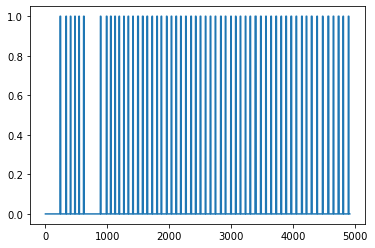

In [101]:
plt.plot(df['rota_squared'].values)

# File 3

In [102]:
ind = 3
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-003\ses-EphysMedOff01\ieeg\sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-003\ses-EphysMedOff01\ieeg\sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-003\ses-EphysMedOff01\ieeg\sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_channels.tsv.
sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg


<ipython-input-102-8dd674e3aa8e>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-003\**\sub-003_ses-EphysMedOff01*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-102-8dd674e3aa8e>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-003\**\sub-003_ses-EphysMedOff01*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [103]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 589104  =      0.000 ...   428.439 secs...


In [104]:
anodes = [
'LFP_R_2_STN_MT',
'LFP_R_3_STN_MT',
'LFP_R_4_STN_MT',
'LFP_R_4_STN_MT',
'LFP_L_2_STN_MT',
'LFP_L_3_STN_MT',
'LFP_L_4_STN_MT',
'LFP_L_4_STN_MT']
cathodes = [
'LFP_R_1_STN_MT',
'LFP_R_2_STN_MT',
'LFP_R_3_STN_MT',
'LFP_R_1_STN_MT',
'LFP_L_1_STN_MT',
'LFP_L_2_STN_MT',
'LFP_L_3_STN_MT',
'LFP_L_1_STN_MT']
new_chs =[
'STN_R_1_2_MT',
'STN_R_2_3_MT',
'STN_R_3_4_MT',
'STN_R_1_4_MT',
'STN_L_1_2_MT',
'STN_L_2_3_MT',
'STN_L_3_4_MT',
'STN_L_1_4_MT',
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=589105
    Range : 0 ... 589104 =      0.000 ...   428.439 secs
Ready.
Added the following bipolar channels:
STN_R_1_2_MT, STN_R_2_3_MT, STN_R_3_4_MT, STN_R_1_4_MT, STN_L_1_2_MT, STN_L_2_3_MT, STN_L_3_4_MT, STN_L_1_4_MT


In [105]:
picks = sorted([
'ECOG_L_1_SMC_AT',
'ECOG_L_2_SMC_AT',
'ECOG_L_3_SMC_AT',
'ECOG_L_4_SMC_AT',
'ECOG_L_5_SMC_AT',
'ECOG_L_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [106]:
raw.ch_names

['ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'STN_L_1_2_MT',
 'STN_L_1_4_MT',
 'STN_L_2_3_MT',
 'STN_L_3_4_MT',
 'STN_R_1_2_MT',
 'STN_R_1_4_MT',
 'STN_R_2_3_MT',
 'STN_R_3_4_MT',
 'rota_squared']

In [107]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 9075 samples (6.600 sec)



In [108]:
raw = raw.resample(sfreq=500)

In [109]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [110]:
tf.shape

(14, 200, 214220)

In [111]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [112]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [113]:
print(raw.annotations)

<Annotations | 138 segments: rotation_end (69), rotation_onset (69)>


In [114]:
events, event_id = mne.events_from_annotations(raw, {'rotation_onset':1,
                                                     'rotation_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<5.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['rotation_end', 'rotation_onset']
Orig. no. of events:  138 , Orig. no. of trials:  69
New no. of events:  100 , New no. of trials:  50
Dropped no. of trials:  19
Intertrial pauses:  [2.816 3.638 3.906 2.856 3.938 3.118 6.778 6.072 5.588 6.046 6.322 6.14
 6.266 5.828 5.428 7.886 7.28  7.396 6.742 6.336 6.78  6.982 6.946 6.06
 6.342 6.104 6.986 5.956 6.536 5.41  6.878 5.156 5.    4.72  5.49  5.144
 5.002 5.424 5.278 5.564 4.724 5.442 5.378 5.378 8.364 5.378 5.094 5.256
 5.19  5.674 5.532 5.274 4.834 5.464 4.792 5.058 5.362 5.394 4.596 4.544
 4.4   5.54  4.42  4.176 4.094 4.872 4.792 4.878]


In [115]:
features['rota_squared'] = onoff[::decim]

In [116]:
df = pd.DataFrame(features)

In [117]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [118]:
df = pd.read_csv(out_file, index_col=None)

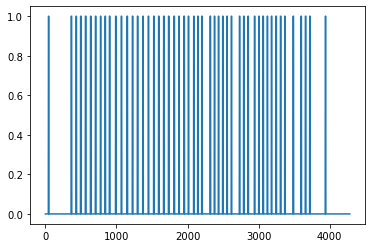

In [119]:
plt.plot(df['rota_squared'].values)

# File 4

In [120]:
ind = 4
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\ses-EphysMedOff01\ieeg\sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\ses-EphysMedOff01\ieeg\sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\ses-EphysMedOff01\ieeg\sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_channels.tsv.
sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg


<ipython-input-120-b5574857510e>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\**\sub-004_ses-EphysMedOff01*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-120-b5574857510e>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\**\sub-004_ses-EphysMedOff01*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [121]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 2103145  =      0.000 ...   513.167 secs...


In [122]:
data = raw.get_data(picks=[
'LFP_R_2_STN_BS',
'LFP_R_3_STN_BS',
'LFP_R_4_STN_BS',
'LFP_R_5_STN_BS',
'LFP_R_6_STN_BS',
'LFP_R_7_STN_BS',
'LFP_L_2_STN_BS',
'LFP_L_3_STN_BS',
'LFP_L_4_STN_BS',
'LFP_L_5_STN_BS',
'LFP_L_6_STN_BS',
'LFP_L_7_STN_BS'])

In [124]:
data_list = list()
for i in np.arange(0, data.shape[0], 3):
    add_data = np.expand_dims(data[i]+data[i+1]+data[i+2], axis=0)
    data_list.append(add_data)
new_data = np.concatenate(data_list, axis=0)

In [125]:
info =  mne.create_info(['LFP_R_234_STN_BS', 'LFP_R_567_STN_BS', 'LFP_L_234_STN_BS', 'LFP_L_567_STN_BS'], 
                        sfreq=raw.info['sfreq'], ch_types='seeg', verbose=None)
raw_new = mne.io.RawArray(new_data, info, first_samp=0, copy='auto', verbose=None)

Creating RawArray with float64 data, n_channels=4, n_times=2103146
    Range : 0 ... 2103145 =      0.000 ...   513.167 secs
Ready.


In [126]:
raw = raw.add_channels([raw_new], force_update_info=True)

ValueError: The following channels are present in more than one input measurement info objects: ['LFP_R_234_STN_BS', 'LFP_L_234_STN_BS', 'LFP_L_567_STN_BS', 'LFP_R_567_STN_BS']

In [127]:
raw.ch_names

['ACC_L_X_D2_TM',
 'ACC_L_Y_D2_TM',
 'ACC_L_Z_D2_TM',
 'ACC_R_X_D2_TM',
 'ACC_R_Y_D2_TM',
 'ACC_R_Z_D2_TM',
 'ANALOG_R_ROTA_CH',
 'ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'EEG_Cz_TM',
 'EEG_Fz_TM',
 'EMG_L_BR_TM',
 'EMG_R_BR_TM',
 'LFP_L_1_STN_BS',
 'LFP_L_2_STN_BS',
 'LFP_L_3_STN_BS',
 'LFP_L_4_STN_BS',
 'LFP_L_5_STN_BS',
 'LFP_L_6_STN_BS',
 'LFP_L_7_STN_BS',
 'LFP_L_8_STN_BS',
 'LFP_R_1_STN_BS',
 'LFP_R_2_STN_BS',
 'LFP_R_3_STN_BS',
 'LFP_R_4_STN_BS',
 'LFP_R_5_STN_BS',
 'LFP_R_6_STN_BS',
 'LFP_R_7_STN_BS',
 'LFP_R_8_STN_BS',
 'rota_squared',
 'LFP_R_234_STN_BS',
 'LFP_R_567_STN_BS',
 'LFP_L_234_STN_BS',
 'LFP_L_567_STN_BS']

In [128]:
anodes = [
'LFP_R_8_STN_BS',
'LFP_R_8_STN_BS',
'LFP_R_567_STN_BS',
'LFP_R_234_STN_BS',
'LFP_L_8_STN_BS',
'LFP_L_8_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_234_STN_BS']
cathodes = [
'LFP_R_1_STN_BS',
'LFP_R_567_STN_BS',
'LFP_R_234_STN_BS',
'LFP_R_1_STN_BS',
'LFP_L_1_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_234_STN_BS',
'LFP_L_1_STN_BS']
new_chs =[
'STN_R_1_8_BS',
'STN_R_567_8_BS',
'STN_R_234_567_BS',
'STN_R_1_234_BS',
'STN_L_1_8_BS',
'STN_L_567_8_BS',
'STN_L_234_567_BS',
'STN_L_1_234_BS'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=2103146
    Range : 0 ... 2103145 =      0.000 ...   513.167 secs
Ready.
Added the following bipolar channels:
STN_R_1_8_BS, STN_R_567_8_BS, STN_R_234_567_BS, STN_R_1_234_BS, STN_L_1_8_BS, STN_L_567_8_BS, STN_L_234_567_BS, STN_L_1_234_BS


In [129]:
picks = sorted([
'ECOG_L_1_SMC_AT',
'ECOG_L_2_SMC_AT',
'ECOG_L_3_SMC_AT',
'ECOG_L_4_SMC_AT',
'ECOG_L_5_SMC_AT',
'ECOG_L_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [130]:
raw.ch_names

['ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'STN_L_1_234_BS',
 'STN_L_1_8_BS',
 'STN_L_234_567_BS',
 'STN_L_567_8_BS',
 'STN_R_1_234_BS',
 'STN_R_1_8_BS',
 'STN_R_234_567_BS',
 'STN_R_567_8_BS',
 'rota_squared']

In [131]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 27051 samples (6.600 sec)



In [132]:
raw = raw.resample(sfreq=500)

In [133]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [134]:
tf.shape

(14, 200, 256584)

In [135]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [136]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [137]:
print(raw.annotations)

<Annotations | 200 segments: emg_end (50), emg_onset (50), movement_end ...>


In [139]:
events, event_id = mne.events_from_annotations(raw, {'emg_onset':1,
                                                     'emg_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<5.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['emg_end', 'emg_onset']
Orig. no. of events:  100 , Orig. no. of trials:  50
New no. of events:  100 , New no. of trials:  50
Dropped no. of trials:  0
Intertrial pauses:  [12.566  8.75   8.398  7.224  8.09   7.67   7.532  8.302  7.646  7.944
  8.21   8.932  8.186  9.334 10.152  7.942 10.356  8.534  7.85   8.636
  7.704  8.354  8.456  9.922  7.046  8.056  7.622  6.31   8.344  7.972
  6.654  6.928  6.87   6.096  7.008  7.366  7.13   6.982  5.51   6.234
  6.554  7.124  5.64   5.984  5.496  6.44   7.74   5.59   5.854]


In [140]:
features['rota_squared'] = onoff[::decim]

In [141]:
df = pd.DataFrame(features)

In [142]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [143]:
df = pd.read_csv(out_file, index_col=None)

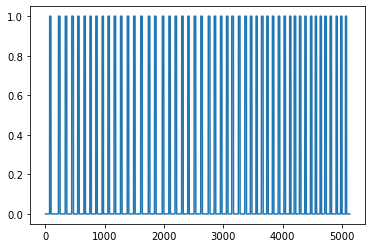

In [144]:
plt.plot(df['rota_squared'].values)

# File 5

In [145]:
ind = 5
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\ses-EphysMedOn01\ieeg\sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\ses-EphysMedOn01\ieeg\sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\ses-EphysMedOn01\ieeg\sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_channels.tsv.
sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg


<ipython-input-145-1d0c3af18b55>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\**\sub-004_ses-EphysMedOn01*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-145-1d0c3af18b55>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-004\**\sub-004_ses-EphysMedOn01*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [146]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 1477870  =      0.000 ...   360.600 secs...


In [147]:
data = raw.get_data(picks=[
'LFP_R_2_STN_BS',
'LFP_R_3_STN_BS',
'LFP_R_4_STN_BS',
'LFP_R_5_STN_BS',
'LFP_R_6_STN_BS',
'LFP_R_7_STN_BS',
'LFP_L_2_STN_BS',
'LFP_L_3_STN_BS',
'LFP_L_4_STN_BS',
'LFP_L_5_STN_BS',
'LFP_L_6_STN_BS',
'LFP_L_7_STN_BS'])

In [148]:
data.shape

(12, 1477871)

In [149]:
data_list = list()
for i in np.arange(0, data.shape[0], 3):
    add_data = np.expand_dims(data[i]+data[i+1]+data[i+2], axis=0)
    data_list.append(add_data)
new_data = np.concatenate(data_list, axis=0)

In [150]:
info =  mne.create_info(['LFP_R_234_STN_BS', 'LFP_R_567_STN_BS', 'LFP_L_234_STN_BS', 'LFP_L_567_STN_BS'], 
                        sfreq=raw.info['sfreq'], ch_types='seeg', verbose=None)
raw_new = mne.io.RawArray(new_data, info, first_samp=0, copy='auto', verbose=None)

Creating RawArray with float64 data, n_channels=4, n_times=1477871
    Range : 0 ... 1477870 =      0.000 ...   360.600 secs
Ready.


In [151]:
raw = raw.add_channels([raw_new], force_update_info=True)

ValueError: The following channels are present in more than one input measurement info objects: ['LFP_R_234_STN_BS', 'LFP_L_234_STN_BS', 'LFP_L_567_STN_BS', 'LFP_R_567_STN_BS']

In [152]:
raw.ch_names

['ACC_L_X_D2_TM',
 'ACC_L_Y_D2_TM',
 'ACC_L_Z_D2_TM',
 'ACC_R_X_D2_TM',
 'ACC_R_Y_D2_TM',
 'ACC_R_Z_D2_TM',
 'ANALOG_R_ROTA_CH',
 'ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'EEG_Cz_TM',
 'EEG_Fz_TM',
 'EMG_L_BR_TM',
 'EMG_R_BR_TM',
 'LFP_L_1_STN_BS',
 'LFP_L_2_STN_BS',
 'LFP_L_3_STN_BS',
 'LFP_L_4_STN_BS',
 'LFP_L_5_STN_BS',
 'LFP_L_6_STN_BS',
 'LFP_L_7_STN_BS',
 'LFP_L_8_STN_BS',
 'LFP_R_1_STN_BS',
 'LFP_R_2_STN_BS',
 'LFP_R_3_STN_BS',
 'LFP_R_4_STN_BS',
 'LFP_R_5_STN_BS',
 'LFP_R_6_STN_BS',
 'LFP_R_7_STN_BS',
 'LFP_R_8_STN_BS',
 'rota_squared',
 'LFP_R_234_STN_BS',
 'LFP_R_567_STN_BS',
 'LFP_L_234_STN_BS',
 'LFP_L_567_STN_BS']

In [153]:
anodes = [
'LFP_R_8_STN_BS',
'LFP_R_8_STN_BS',
'LFP_R_567_STN_BS',
'LFP_R_234_STN_BS',
'LFP_L_8_STN_BS',
'LFP_L_8_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_234_STN_BS']
cathodes = [
'LFP_R_1_STN_BS',
'LFP_R_567_STN_BS',
'LFP_R_234_STN_BS',
'LFP_R_1_STN_BS',
'LFP_L_1_STN_BS',
'LFP_L_567_STN_BS',
'LFP_L_234_STN_BS',
'LFP_L_1_STN_BS']
new_chs =[
'STN_R_1_8_BS',
'STN_R_567_8_BS',
'STN_R_234_567_BS',
'STN_R_1_234_BS',
'STN_L_1_8_BS',
'STN_L_567_8_BS',
'STN_L_234_567_BS',
'STN_L_1_234_BS'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=1477871
    Range : 0 ... 1477870 =      0.000 ...   360.600 secs
Ready.
Added the following bipolar channels:
STN_R_1_8_BS, STN_R_567_8_BS, STN_R_234_567_BS, STN_R_1_234_BS, STN_L_1_8_BS, STN_L_567_8_BS, STN_L_234_567_BS, STN_L_1_234_BS


In [154]:
picks = sorted([
'ECOG_L_1_SMC_AT',
'ECOG_L_2_SMC_AT',
'ECOG_L_3_SMC_AT',
'ECOG_L_4_SMC_AT',
'ECOG_L_5_SMC_AT',
'ECOG_L_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [155]:
raw.ch_names

['ECOG_L_1_SMC_AT',
 'ECOG_L_2_SMC_AT',
 'ECOG_L_3_SMC_AT',
 'ECOG_L_4_SMC_AT',
 'ECOG_L_5_SMC_AT',
 'ECOG_L_6_SMC_AT',
 'STN_L_1_234_BS',
 'STN_L_1_8_BS',
 'STN_L_234_567_BS',
 'STN_L_567_8_BS',
 'STN_R_1_234_BS',
 'STN_R_1_8_BS',
 'STN_R_234_567_BS',
 'STN_R_567_8_BS',
 'rota_squared']

In [156]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 27051 samples (6.600 sec)



In [157]:
raw = raw.resample(sfreq=500)

In [158]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [159]:
tf.shape

(14, 200, 180300)

In [160]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [161]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [162]:
print(raw.annotations)

<Annotations | 192 segments: emg_end (32), emg_onset (32), movement_end ...>


In [176]:
events, event_id = mne.events_from_annotations(raw, {'rotation_onset':1,
                                                     'rotation_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<2.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['rotation_end', 'rotation_onset']
Orig. no. of events:  64 , Orig. no. of trials:  32
New no. of events:  64 , New no. of trials:  32
Dropped no. of trials:  0
Intertrial pauses:  [ 6.416  6.188  5.38   6.524  8.372  6.78   6.026  5.244  4.92   4.678
 10.03   6.254  6.836  7.792  8.17   6.35   6.834  6.376  9.154  7.684
  8.372  6.956  7.94   6.388  5.284  8.304  6.146 10.42   8.29   5.742
  6.12 ]


In [177]:
features['rota_squared'] = onoff[::decim]

In [178]:
df = pd.DataFrame(features)

In [179]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [180]:
df = pd.read_csv(out_file, index_col=None)

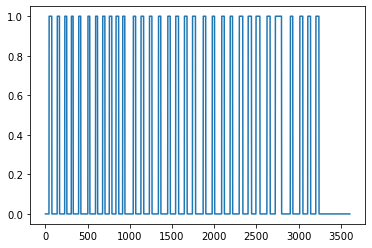

In [181]:
plt.plot(df['rota_squared'].values)

# File 6

In [185]:
ind = 6
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\ses-EphysMedOff01\ieeg\sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\ses-EphysMedOff01\ieeg\sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\ses-EphysMedOff01\ieeg\sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_channels.tsv.
sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg


<ipython-input-185-f47314dd2f4b>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\**\sub-005_ses-EphysMedOff01*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-185-f47314dd2f4b>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\**\sub-005_ses-EphysMedOff01*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [186]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 3238798  =      0.000 ...   809.699 secs...


In [188]:
anodes = [
'LFP_R_234_STN_MT',
'LFP_R_567_STN_MT',
'LFP_R_8_STN_MT',
'LFP_R_8_STN_MT',
'LFP_L_234_STN_MT',
'LFP_L_567_STN_MT',
'LFP_L_8_STN_MT',
'LFP_L_8_STN_MT']
cathodes = [
'LFP_R_1_STN_MT',
'LFP_R_234_STN_MT',
'LFP_R_567_STN_MT',
'LFP_R_1_STN_MT',
'LFP_L_1_STN_MT',
'LFP_L_234_STN_MT',
'LFP_L_567_STN_MT',
'LFP_L_1_STN_MT']
new_chs =[
'STN_R_1_234',
'STN_R_234_567',
'STN_R_567_8',
'STN_R_1_8',
'STN_L_1_234',
'STN_L_234_567',
'STN_L_567_8',
'STN_L_1_8'  
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=3238799
    Range : 0 ... 3238798 =      0.000 ...   809.699 secs
Ready.
Added the following bipolar channels:
STN_R_1_234, STN_R_234_567, STN_R_567_8, STN_R_1_8, STN_L_1_234, STN_L_234_567, STN_L_567_8, STN_L_1_8


In [190]:
picks = sorted([
'ECOG_R_1_SMC_AT',
'ECOG_R_2_SMC_AT',
'ECOG_R_3_SMC_AT',
'ECOG_R_4_SMC_AT',
'ECOG_R_5_SMC_AT',
'ECOG_R_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [191]:
raw.ch_names

['ECOG_R_1_SMC_AT',
 'ECOG_R_2_SMC_AT',
 'ECOG_R_3_SMC_AT',
 'ECOG_R_4_SMC_AT',
 'ECOG_R_5_SMC_AT',
 'ECOG_R_6_SMC_AT',
 'STN_L_1_234',
 'STN_L_1_8',
 'STN_L_234_567',
 'STN_L_567_8',
 'STN_R_1_234',
 'STN_R_1_8',
 'STN_R_234_567',
 'STN_R_567_8',
 'rota_squared']

In [192]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 26401 samples (6.600 sec)



In [193]:
raw = raw.resample(sfreq=500)

In [194]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [195]:
tf.shape

(14, 200, 404850)

In [196]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [197]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [198]:
print(raw.annotations)

<Annotations | 118 segments: rotation_end (59), rotation_onset (59)>


In [199]:
events, event_id = mne.events_from_annotations(raw, {'rotation_onset':1,
                                                     'rotation_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<2.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['rotation_end', 'rotation_onset']
Orig. no. of events:  118 , Orig. no. of trials:  59
New no. of events:  118 , New no. of trials:  59
Dropped no. of trials:  0
Intertrial pauses:  [ 7.56   5.346  6.89   6.25   7.18   6.95   6.892 11.316 10.236  9.83
 10.154  6.952 11.216 10.138 12.096 15.424 13.774 15.368 14.108  9.864
 11.58   9.742 10.322 10.388  6.512  7.796 12.094  9.114  4.314 15.554
  8.552  7.618  5.978  8.256 11.932  7.146  7.236  6.6    9.578 14.322
 10.35  11.186  8.584  6.322  6.112  8.646  8.384  7.496  6.978 10.478
 10.942  9.074  6.972  8.104  6.33  11.298  9.83   8.87 ]


In [200]:
features['rota_squared'] = onoff[::decim]

In [201]:
df = pd.DataFrame(features)

In [202]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [203]:
df = pd.read_csv(out_file, index_col=None)

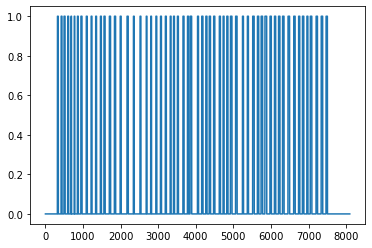

In [204]:
plt.plot(df['rota_squared'].values)

# File 7

In [205]:
ind = 7
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\ses-EphysMedOn01\ieeg\sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\ses-EphysMedOn01\ieeg\sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\ses-EphysMedOn01\ieeg\sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_channels.tsv.
sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg


<ipython-input-205-70b3ce6a20f0>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\**\sub-005_ses-EphysMedOn01*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-205-70b3ce6a20f0>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-005\**\sub-005_ses-EphysMedOn01*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [206]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 2816451  =      0.000 ...   704.113 secs...


In [208]:
anodes = [
'LFP_R_234_STN_MT',
'LFP_R_567_STN_MT',
'LFP_R_8_STN_MT',
'LFP_R_8_STN_MT',
'LFP_L_234_STN_MT',
'LFP_L_567_STN_MT',
'LFP_L_8_STN_MT',
'LFP_L_8_STN_MT']
cathodes = [
'LFP_R_1_STN_MT',
'LFP_R_234_STN_MT',
'LFP_R_567_STN_MT',
'LFP_R_1_STN_MT',
'LFP_L_1_STN_MT',
'LFP_L_234_STN_MT',
'LFP_L_567_STN_MT',
'LFP_L_1_STN_MT']
new_chs =[
'STN_R_1_234',
'STN_R_234_567',
'STN_R_567_8',
'STN_R_1_8',
'STN_L_1_234',
'STN_L_234_567',
'STN_L_567_8',
'STN_L_1_8'  
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False, verbose=False)

In [209]:
picks = sorted([
'ECOG_R_1_SMC_AT',
'ECOG_R_2_SMC_AT',
'ECOG_R_3_SMC_AT',
'ECOG_R_4_SMC_AT',
'ECOG_R_5_SMC_AT',
'ECOG_R_6_SMC_AT']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [210]:
raw.ch_names

['ECOG_R_1_SMC_AT',
 'ECOG_R_2_SMC_AT',
 'ECOG_R_3_SMC_AT',
 'ECOG_R_4_SMC_AT',
 'ECOG_R_5_SMC_AT',
 'ECOG_R_6_SMC_AT',
 'STN_L_1_234',
 'STN_L_1_8',
 'STN_L_234_567',
 'STN_L_567_8',
 'STN_R_1_234',
 'STN_R_1_8',
 'STN_R_234_567',
 'STN_R_567_8',
 'rota_squared']

In [211]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 26401 samples (6.600 sec)



In [212]:
raw = raw.resample(sfreq=500)

In [213]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [214]:
tf.shape

(14, 200, 352056)

In [215]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [216]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [217]:
print(raw.annotations)

<Annotations | 116 segments: rotation_end (58), rotation_onset (58)>


In [218]:
events, event_id = mne.events_from_annotations(raw, {'rotation_onset':1,
                                                     'rotation_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<2.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['rotation_end', 'rotation_onset']
Orig. no. of events:  116 , Orig. no. of trials:  58
New no. of events:  116 , New no. of trials:  58
Dropped no. of trials:  0
Intertrial pauses:  [11.202 12.052 13.65  14.444 13.514 12.63  12.012 13.436 11.684 13.412
 13.572 12.05  13.644 13.042 14.5   11.792 12.854 10.728 17.524 11.826
 12.042 11.794 12.09  13.754  9.624  9.94  11.184 11.36   8.282  7.958
  7.192  8.796 10.168  7.358  9.048  3.536  5.558  7.352  7.824  6.572
  6.17   5.03   6.646  5.81   4.524  7.782  6.188  9.514  7.     6.198
  7.424  7.438  4.16   7.696  5.398  4.944 10.996]


In [219]:
features['rota_squared'] = onoff[::decim]

In [220]:
df = pd.DataFrame(features)

In [221]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [222]:
df = pd.read_csv(out_file, index_col=None)

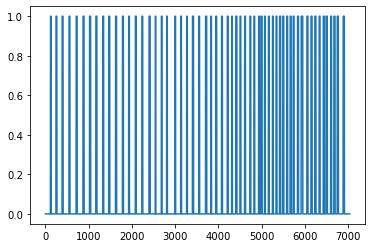

In [223]:
plt.plot(df['rota_squared'].values)

# Beijing

In [227]:
root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26'
source_files = get_all_files(
    path=root,
    suffix='vhdr',
    get_bids=True,
    prefix='ButtonPress',
    bids_root=root,
    verbose=True,
    extension=None)
out_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26_rereference-ECOG\derivatives\feat_mne_tf'

Corresponding files found:
0 : sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr
1 : sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr
2 : sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr
3 : sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr


In [228]:
files = source_files

# File 0

In [229]:
ind = 0
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG006\ses-EphysMedOn\ieeg\sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG006\ses-EphysMedOn\ieeg\sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG006\ses-EphysMedOn\ieeg\sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_channels.tsv.
sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg


<ipython-input-229-5e5ae28f0de3>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG006\**\sub-FOG006_ses-EphysMedOn*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-229-5e5ae28f0de3>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG006\**\sub-FOG006_ses-EphysMedOn*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [230]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 1312097  =      0.000 ...   656.048 secs...


In [231]:
anodes = [
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_L_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI',
    'LFP_R_4_STN_PI']
cathodes = [
    'LFP_L_4_STN_PI',
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_R_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI']
new_chs =[
    'LFP_L_4_1_STN_PI',
    'LFP_L_2_1_STN_PI',
    'LFP_L_3_2_STN_PI',
    'LFP_L_4_3_STN_PI',
    'LFP_R_4_1_STN_PI',
    'LFP_R_2_1_STN_PI',
    'LFP_R_3_2_STN_PI',
    'LFP_R_4_3_STN_PI'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=1312098
    Range : 0 ... 1312097 =      0.000 ...   656.048 secs
Ready.
Added the following bipolar channels:
LFP_L_4_1_STN_PI, LFP_L_2_1_STN_PI, LFP_L_3_2_STN_PI, LFP_L_4_3_STN_PI, LFP_R_4_1_STN_PI, LFP_R_2_1_STN_PI, LFP_R_3_2_STN_PI, LFP_R_4_3_STN_PI


In [232]:
raw.ch_names

['ECOG_R_1_SM_HH',
 'ECOG_R_2_SM_HH',
 'ECOG_R_3_SM_HH',
 'ECOG_R_4_SM_HH',
 'ECOG_R_5_SM_HH',
 'ECOG_R_6_SM_HH',
 'ECOG_R_7_SM_HH',
 'ECOG_R_8_SM_HH',
 'EMG_L_1_HAND_PI',
 'EMG_L_2_HAND_PI',
 'EMG_L_RMS_500',
 'EMG_R_1_HAND_PI',
 'EMG_R_2_HAND_PI',
 'EMG_squared',
 'LFP_L_1D_STN_PI',
 'LFP_L_1U_STN_PI',
 'LFP_L_1_STN_PI',
 'LFP_L_2_STN_PI',
 'LFP_L_3_STN_PI',
 'LFP_L_4_STN_PI',
 'LFP_R_1_STN_PI',
 'LFP_R_2_STN_PI',
 'LFP_R_3_STN_PI',
 'LFP_R_4_STN_PI',
 'MISC_10_TTL',
 'MISC_11_NONE',
 'MISC_GROUND',
 'MISC_R_1_STN_PI',
 'MISC_R_2_STN_PI',
 'LFP_L_4_1_STN_PI',
 'LFP_L_2_1_STN_PI',
 'LFP_L_3_2_STN_PI',
 'LFP_L_4_3_STN_PI',
 'LFP_R_4_1_STN_PI',
 'LFP_R_2_1_STN_PI',
 'LFP_R_3_2_STN_PI',
 'LFP_R_4_3_STN_PI']

In [233]:
picks = sorted([
'ECOG_R_1_SM_HH',
 'ECOG_R_2_SM_HH',
 'ECOG_R_3_SM_HH',
 'ECOG_R_4_SM_HH',
 'ECOG_R_5_SM_HH',
 'ECOG_R_6_SM_HH',
 'ECOG_R_7_SM_HH',
 'ECOG_R_8_SM_HH']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [234]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 sec)



In [235]:
raw = raw.resample(sfreq=500)

In [236]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [237]:
tf.shape

(16, 200, 328024)

In [238]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [239]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [240]:
print(raw.annotations)

<Annotations | 310 segments: EMG_end (155), EMG_onset (155)>


In [242]:
try:
    events, event_id = mne.events_from_annotations(
        raw, {'rotation_onset':1, 'rotation_end':-1})
except ValueError:
    events, event_id = mne.events_from_annotations(
        raw, {'EMG_onset':1, 'EMG_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<2.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['EMG_end', 'EMG_onset']
Orig. no. of events:  310 , Orig. no. of trials:  155
New no. of events:  308 , New no. of trials:  154
Dropped no. of trials:  1
Intertrial pauses:  [3.326 4.34  3.598 3.608 2.738 3.616 3.528 3.742 3.506 3.372 3.152 3.346
 4.97  3.804 3.792 3.788 3.81  3.518 3.116 3.574 3.588 3.406 3.432 3.322
 3.494 3.728 3.5   3.378 3.592 3.446 3.646 3.23  3.276 3.26  3.246 3.346
 3.636 3.276 3.216 3.692 3.58  3.342 3.544 3.482 3.256 3.404 3.666 3.562
 3.134 3.404 2.868 3.526 3.08  3.55  3.784 3.196 2.796 3.408 3.214 3.224
 3.082 3.158 3.62  3.374 3.422 4.088 3.418 3.476 3.7   3.416 3.188 3.012
 3.348 3.258 3.442 3.452 3.14  2.944 3.436 2.974 3.264 3.15  3.396 3.306
 3.356 2.816 3.164 3.592 3.556 3.024 3.568 3.498 2.706 3.514 2.926 3.488
 3.074 3.554 3.894 3.36  2.932 3.316 3.216 3.1   2.88  3.138 3.57  4.314
 3.058 3.094 3.01  3.35  2.72  2.892 2.818 5.726 3.06  3.04  2.528 2.642
 2.85  1.898 3.16  2.532 2.812 2.974 2.596 2.908 3.34  3.046 2.9

In [243]:
features['rota_squared'] = onoff[::decim]

In [244]:
df = pd.DataFrame(features)

In [245]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [246]:
df = pd.read_csv(out_file, index_col=None)

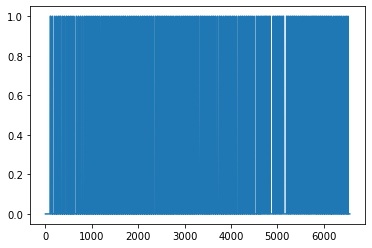

In [247]:
plt.plot(df['rota_squared'].values)

# File 1

In [248]:
ind = 1
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG008\ses-EphysMedOn\ieeg\sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG008\ses-EphysMedOn\ieeg\sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG008\ses-EphysMedOn\ieeg\sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_channels.tsv.
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg


<ipython-input-248-5ed641117454>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG008\**\sub-FOG008_ses-EphysMedOn*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-248-5ed641117454>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG008\**\sub-FOG008_ses-EphysMedOn*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [249]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 1945106  =      0.000 ...   972.553 secs...


In [250]:
anodes = [
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_L_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI',
    'LFP_R_4_STN_PI']
cathodes = [
    'LFP_L_4_STN_PI',
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_R_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI']
new_chs =[
    'LFP_L_4_1_STN_PI',
    'LFP_L_2_1_STN_PI',
    'LFP_L_3_2_STN_PI',
    'LFP_L_4_3_STN_PI',
    'LFP_R_4_1_STN_PI',
    'LFP_R_2_1_STN_PI',
    'LFP_R_3_2_STN_PI',
    'LFP_R_4_3_STN_PI'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=1945107
    Range : 0 ... 1945106 =      0.000 ...   972.553 secs
Ready.
Added the following bipolar channels:
LFP_L_4_1_STN_PI, LFP_L_2_1_STN_PI, LFP_L_3_2_STN_PI, LFP_L_4_3_STN_PI, LFP_R_4_1_STN_PI, LFP_R_2_1_STN_PI, LFP_R_3_2_STN_PI, LFP_R_4_3_STN_PI


In [251]:
picks = sorted([
'ECOG_R_1_SM_HH',
 'ECOG_R_2_SM_HH',
 'ECOG_R_3_SM_HH',
 'ECOG_R_4_SM_HH',
 'ECOG_R_5_SM_HH',
 'ECOG_R_6_SM_HH',
 'ECOG_R_7_SM_HH',
 'ECOG_R_8_SM_HH']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [252]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 sec)



In [253]:
raw = raw.resample(sfreq=500)

In [254]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [255]:
tf.shape

(16, 200, 486277)

In [256]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [257]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [258]:
print(raw.annotations)

<Annotations | 118 segments: EMG_end (59), EMG_onset (59)>


In [259]:
try:
    events, event_id = mne.events_from_annotations(
        raw, {'rotation_onset':1, 'rotation_end':-1})
except ValueError:
    events, event_id = mne.events_from_annotations(
        raw, {'EMG_onset':1, 'EMG_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<2.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['EMG_end', 'EMG_onset']
Orig. no. of events:  118 , Orig. no. of trials:  59
New no. of events:  116 , New no. of trials:  58
Dropped no. of trials:  1
Intertrial pauses:  [ 8.876 11.472 12.688 12.272 18.598  9.716 10.284 13.756 12.394  8.19
 24.402  9.616 15.11  16.088 10.15  11.552  8.356 16.752 11.01  22.164
 22.508  9.89  15.31  19.962  1.314 18.748 27.668 15.636 22.23  24.498
 23.766  2.822  6.258 29.33  18.592 24.082 27.882 26.638 13.372  9.174
 18.148 20.134  9.796 10.86  10.662  9.772 18.368  2.78  39.934  8.7
  9.794 13.818 27.184  8.494 13.304 10.388 44.658 16.368]


In [260]:
features['rota_squared'] = onoff[::decim]

In [261]:
df = pd.DataFrame(features)

In [262]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [263]:
df = pd.read_csv(out_file, index_col=None)

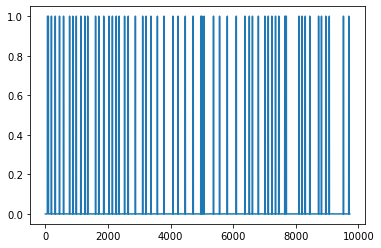

In [264]:
plt.plot(df['rota_squared'].values)

# File 2

In [265]:
ind = 2
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG010\ses-EphysMedOff\ieeg\sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG010\ses-EphysMedOff\ieeg\sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG010\ses-EphysMedOff\ieeg\sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_channels.tsv.
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg


<ipython-input-265-8b3f50adc590>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG010\**\sub-FOG010_ses-EphysMedOff*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-265-8b3f50adc590>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOG010\**\sub-FOG010_ses-EphysMedOff*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [266]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 1190447  =      0.000 ...   595.223 secs...


In [267]:
anodes = [
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_L_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI',
    'LFP_R_4_STN_PI']
cathodes = [
    'LFP_L_4_STN_PI',
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_R_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI']
new_chs =[
    'LFP_L_4_1_STN_PI',
    'LFP_L_2_1_STN_PI',
    'LFP_L_3_2_STN_PI',
    'LFP_L_4_3_STN_PI',
    'LFP_R_4_1_STN_PI',
    'LFP_R_2_1_STN_PI',
    'LFP_R_3_2_STN_PI',
    'LFP_R_4_3_STN_PI'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=1190448
    Range : 0 ... 1190447 =      0.000 ...   595.223 secs
Ready.
Added the following bipolar channels:
LFP_L_4_1_STN_PI, LFP_L_2_1_STN_PI, LFP_L_3_2_STN_PI, LFP_L_4_3_STN_PI, LFP_R_4_1_STN_PI, LFP_R_2_1_STN_PI, LFP_R_3_2_STN_PI, LFP_R_4_3_STN_PI


In [268]:
picks = sorted([
'ECOG_R_1_SM_HH',
 'ECOG_R_2_SM_HH',
 'ECOG_R_3_SM_HH',
 'ECOG_R_4_SM_HH',
 'ECOG_R_5_SM_HH',
 'ECOG_R_6_SM_HH',
 'ECOG_R_7_SM_HH',
 'ECOG_R_8_SM_HH']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [269]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 sec)



In [270]:
raw = raw.resample(sfreq=500)

In [271]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [272]:
tf.shape

(16, 200, 297612)

In [273]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [274]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [275]:
print(raw.annotations)

<Annotations | 204 segments: EMG_end (102), EMG_onset (102)>


In [276]:
try:
    events, event_id = mne.events_from_annotations(
        raw, {'rotation_onset':1, 'rotation_end':-1})
except ValueError:
    events, event_id = mne.events_from_annotations(
        raw, {'EMG_onset':1, 'EMG_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<2.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['EMG_end', 'EMG_onset']
Orig. no. of events:  204 , Orig. no. of trials:  102
New no. of events:  188 , New no. of trials:  94
Dropped no. of trials:  8
Intertrial pauses:  [ 5.554  5.77   9.626  1.618  0.62   0.406  0.512  0.324  0.378  0.296
  0.674 12.536  5.588  4.994  5.69  12.816  4.374  4.506  6.772  5.946
  5.346  4.79   6.082  4.678  5.016  5.304  5.456  5.632  6.896  5.144
  6.152  6.384  5.776  4.916  5.186  7.638  5.184 12.096  5.78   6.856
  4.236  4.078  5.226  5.452  5.57   5.676  4.97   4.47   6.026  4.504
  5.14   4.314  4.648  5.38   6.32   5.002  5.002  8.798  5.456  5.606
  5.97   5.21   7.6    4.972  3.95   4.692  5.266  5.402  5.71   5.582
  5.95   7.586  5.696  5.846  6.004  4.542  5.94   6.     5.712  6.072
  6.254  6.322  5.814  5.708  6.636  6.14   6.6    6.442  6.     6.028
  4.118  3.398  3.174  2.616  3.48   4.186  4.472  3.362  2.406  2.146
  2.288]


In [277]:
features['rota_squared'] = onoff[::decim]

In [278]:
df = pd.DataFrame(features)

In [279]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [280]:
df = pd.read_csv(out_file, index_col=None)

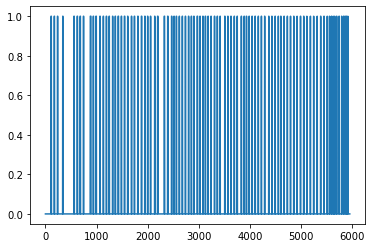

In [281]:
plt.plot(df['rota_squared'].values)

# File 3

In [282]:
ind = 3
raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
print(files[ind].basename)
#raw.plot(scalings='auto')

Extracting parameters from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOGC001\ses-EphysMedOff\ieeg\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOGC001\ses-EphysMedOff\ieeg\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_events.tsv.
Reading channel info from C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOGC001\ses-EphysMedOff\ieeg\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_channels.tsv.
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg


<ipython-input-282-8dd674e3aa8e>:2: RuntimeWarning: Did not find any electrodes.tsv associated with sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOGC001\**\sub-FOGC001_ses-EphysMedOff*electrodes.tsv"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)
<ipython-input-282-8dd674e3aa8e>:2: RuntimeWarning: Did not find any coordsystem.json associated with sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01.

The search_str was "C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\sub-FOGC001\**\sub-FOGC001_ses-EphysMedOff*coordsystem.json"
  raw_orig = mne_bids.read_raw_bids(files[ind], verbose=False)


In [283]:
raw = raw_orig.copy().load_data().set_eeg_reference(
    ref_channels='average', ch_type='ecog', verbose=False)

Reading 0 ... 1276660  =      0.000 ...   638.330 secs...


In [284]:
anodes = [
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_L_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI',
    'LFP_R_4_STN_PI']
cathodes = [
    'LFP_L_4_STN_PI',
    'LFP_L_1_STN_PI',
    'LFP_L_2_STN_PI',
    'LFP_L_3_STN_PI',
    'LFP_R_4_STN_PI',
    'LFP_R_1_STN_PI',
    'LFP_R_2_STN_PI',
    'LFP_R_3_STN_PI']
new_chs =[
    'LFP_L_4_1_STN_PI',
    'LFP_L_2_1_STN_PI',
    'LFP_L_3_2_STN_PI',
    'LFP_L_4_3_STN_PI',
    'LFP_R_4_1_STN_PI',
    'LFP_R_2_1_STN_PI',
    'LFP_R_3_2_STN_PI',
    'LFP_R_4_3_STN_PI'
]
raw = mne.set_bipolar_reference(
    raw, anodes, cathodes, ch_name=new_chs, drop_refs=False)

ECoG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=8, n_times=1276661
    Range : 0 ... 1276660 =      0.000 ...   638.330 secs
Ready.
Added the following bipolar channels:
LFP_L_4_1_STN_PI, LFP_L_2_1_STN_PI, LFP_L_3_2_STN_PI, LFP_L_4_3_STN_PI, LFP_R_4_1_STN_PI, LFP_R_2_1_STN_PI, LFP_R_3_2_STN_PI, LFP_R_4_3_STN_PI


In [285]:
picks = sorted([
'ECOG_R_1_SM_HH',
 'ECOG_R_2_SM_HH',
 'ECOG_R_3_SM_HH',
 'ECOG_R_4_SM_HH',
 'ECOG_R_5_SM_HH',
 'ECOG_R_6_SM_HH',
 'ECOG_R_7_SM_HH',
 'ECOG_R_8_SM_HH']+new_chs+[ch for ch in raw.ch_names if "squared" in ch])
raw = raw.pick_channels(picks, ordered=True)

In [286]:
freqs = np.arange(50, 200, 50)
raw = raw.notch_filter(freqs=freqs)

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 sec)



In [287]:
raw = raw.resample(sfreq=500)

In [288]:
freqs = np.arange(1, 201, 1)
power = mne.decoding.TimeFrequency(
    freqs, sfreq=raw.info['sfreq'], method='morlet', n_cycles=5, 
    output='power')
tf = np.squeeze(power.transform(np.expand_dims(
    raw.get_data(picks='data'), axis=0)))

In [289]:
tf.shape

(16, 200, 319165)

In [290]:
ranges = {'theta': np.arange(4, 9)-1,
          'alpha': np.arange(8, 13)-1,
          'low beta': np.arange(13, 21)-1,
          'high beta': np.arange(20, 36)-1,
          'low gamma': np.arange(60, 81)-1,
          'high gamma': np.arange(90, 201)-1}
bp = dict()
for key in ranges.keys():
    bp[key] = np.mean(tf[:, ranges[key], :], axis=1)

In [291]:
features = dict()
new_sfreq = 10
decim = int(raw.info['sfreq'] / new_sfreq)
for key in bp.keys():
    for i, ch in enumerate(raw.ch_names[:-1]):
        features[ch+'_morlet_power_'+key] = bp[key][i, ::decim]

In [292]:
print(raw.annotations)

<Annotations | 126 segments: EMG_end (63), EMG_onset (63)>


In [293]:
try:
    events, event_id = mne.events_from_annotations(
        raw, {'rotation_onset':1, 'rotation_end':-1})
except ValueError:
    events, event_id = mne.events_from_annotations(
        raw, {'EMG_onset':1, 'EMG_end':-1})
data = raw.get_data()
diff = np.diff(events[:,0])[1::2]/raw.info['sfreq']
bads = np.where(diff<2.)
onsets = np.add(bads, 1)*2
ends = np.add(onsets, 1)
dels = np.hstack((onsets, ends))
events_new = np.delete(events, dels, axis=0)
print('Orig. no. of events: ', len(events), 
      ', Orig. no. of trials: ', len(events)//2)
print('New no. of events: ', len(events_new), 
      ', New no. of trials: ', len(events_new)//2)
print('Dropped no. of trials: ', len(events)//2-len(events_new)//2)
print('Intertrial pauses: ', 
      np.diff(events[:,0])[1::2]/raw.info['sfreq'])
events = events_new
evs_idx = events[:, 0]
onoff = np.zeros(data.shape[1])
for i in np.arange(0, len(evs_idx), 2):
    onoff[evs_idx[i]:evs_idx[i + 1]] = 1

Used Annotations descriptions: ['EMG_end', 'EMG_onset']
Orig. no. of events:  126 , Orig. no. of trials:  63
New no. of events:  126 , New no. of trials:  63
Dropped no. of trials:  0
Intertrial pauses:  [ 4.816  5.214  4.528  5.076  6.32   6.226  6.054  6.862  7.408  5.682
  6.208  6.504  7.26   7.15   6.852  8.232  7.864  7.364  7.598  8.734
  7.502  7.846  8.442  9.756  8.672  9.994 10.29   9.626  9.816 11.594
 10.874 10.566  8.906 12.626 10.966 12.322 13.408 15.448 12.752 13.084
 12.278  9.904  9.78  11.224 11.742 11.532 11.204  9.718 10.432 10.322
 10.276  9.988 10.248 10.126 11.632 11.736  9.25   9.416 11.686 11.882
 13.518 12.522]


In [294]:
features['rota_squared'] = onoff[::decim]

In [295]:
df = pd.DataFrame(features)

In [296]:
out_path = os.path.join(out_root, files[ind].basename)
if not os.path.isdir(out_path):
    os.mkdir(out_path)
out_file = os.path.join(out_path, files[ind].basename + "_FEATURES.csv")
df.to_csv(out_file, index=False)

In [297]:
df = pd.read_csv(out_file, index_col=None)

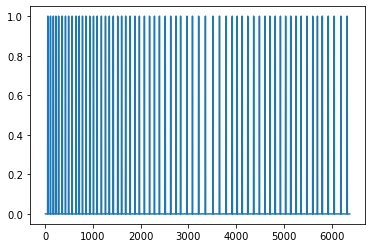

In [298]:
plt.plot(df['rota_squared'].values)